# 姓名：[李林泽]
# 学号：[230490219]

---
## 描述你的大作业

1. 算法的目标
**Canny 边缘检测算法**的目标是：

&gt; 从数字图像中提取出清晰的物体轮廓边缘，同时抑制噪声干扰，实现精确定位。

### 为什么选 Canny 而不是简单边缘检测？
| 特性 | Sobel 边缘检测 | Canny 边缘检测 |
|------|---------------|---------------|
| 抗噪能力 | 弱 | 强（先高斯滤波） |
| 边缘定位 | 较粗 | 精细（NMS 细化） |
| 边缘连续性 | 断裂多 | 好（双阈值连接） |
| 计算复杂度 | 低 | 中等 |
2. 原理
Canny 边缘检测分为 **5 个步骤**：

### 2.1 高斯滤波（降噪）

用高斯核与图像卷积，平滑噪声：

$$G(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}}$$

离散化后的 $5 \times 5$ 高斯核（$\sigma=1.4$ 时近似）：

$$
K = \frac{1}{159}
\begin{bmatrix}
2 & 4 & 5 & 4 & 2 \\
4 & 9 & 12 & 9 & 4 \\
5 & 12 & 15 & 12 & 5 \\
4 & 9 & 12 & 9 & 4 \\
2 & 4 & 5 & 4 & 2
\end{bmatrix}
$$

### 2.2 计算梯度幅值和方向

用 Sobel 算子计算 $x$ 和 $y$ 方向偏导：

$$
G_x =
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
* I,
\quad
G_y =
\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}
* I
$$

梯度幅值和方向：

$$M(x,y) = \sqrt{G_x^2 + G_y^2}$$

$$\theta(x,y) = \arctan\left(\frac{G_y}{G_x}\right)$$

### 2.3 非极大值抑制（NMS）

在梯度方向上，只保留局部极大值点，细化边缘：

$$I_{NMS}(x,y) = 
\begin{cases}
M(x,y), & \text{if } M(x,y) &gt; M(x',y') \text{ and } M(x,y) &gt; M(x'',y'') \\
0, & \text{otherwise}
\end{cases}$$

其中 $(x',y')$ 和 $(x'',y'')$ 是梯度方向上相邻两个插值点。

### 2.4 双阈值检测

设定高低阈值 $T_{high}$ 和 $T_{low}$：

- **强边缘**：$M(x,y) \geq T_{high}$
- **弱边缘**：$T_{low} \leq M(x,y) &lt; T_{high}$
- **非边缘**：$M(x,y) &lt; T_{low}$

### 2.5 边缘连接（滞后阈值）

通过连通性分析，将弱边缘与强边缘相连，孤立弱边缘被剔除。
3. 关键函数及核心参数
## 3. 关键函数及核心参数

###核心参数

| 参数 | 类型 | 说明 | 典型值 |
|------|------|------|--------|
| `sigma` | float | 高斯核标准差，控制平滑程度 | $1.0 \sim 2.0$ |
| `kernel_size` | int | 高斯核尺寸，必须为奇数 | $5$ 或 $7$ |
| `low_threshold` | float | 低阈值，弱边缘下限 | $0.05 \sim 0.1$（归一化） |
| `high_threshold` | float | 高阈值，强边缘下限 | $0.15 \sim 0.3$（归一化） |
| `sobel_kernel` | 3×3 Array | Sobel 卷积核 | 固定矩阵 |



- `img_gray`：灰度图像矩阵（2D Array）
- `Gx, Gy`：x/y 方向梯度矩阵
- `M`：梯度幅值矩阵
- `theta`：梯度方向矩阵（角度制或弧度制）
- `strong_edges`：强边缘二值图
- `weak_edges`：弱边缘二值图

---

✅ 图片读取成功！
   尺寸: (574, 1024, 3)
   数据类型: uint8


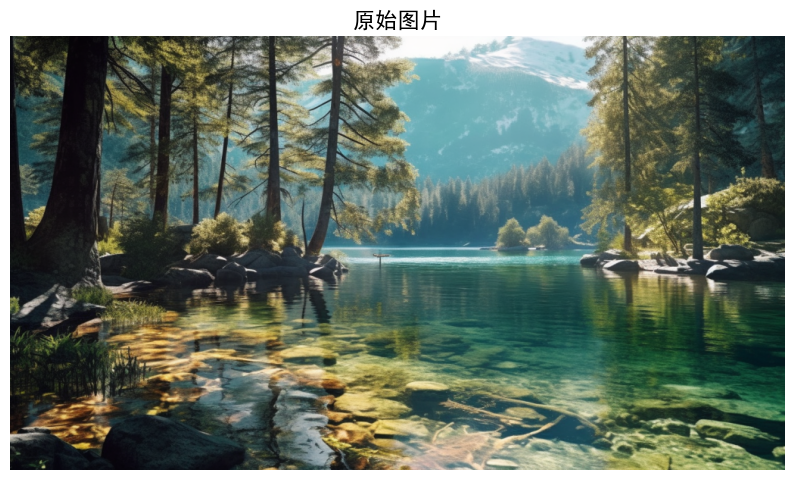

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 读取你的图片（假设图片和 notebook 在同一目录，文件名为 123.jpg）
img = Image.open("123.jpg")
img_array = np.array(img)

print(f"✅ 图片读取成功！")
print(f"   尺寸: {img_array.shape}")
print(f"   数据类型: {img_array.dtype}")

# 显示原图
plt.figure(figsize=(10, 8))
plt.imshow(img_array)
plt.title("原始图片", fontsize=16)
plt.axis('off')
plt.show()

✅ 灰度转换完成！尺寸: (574, 1024)


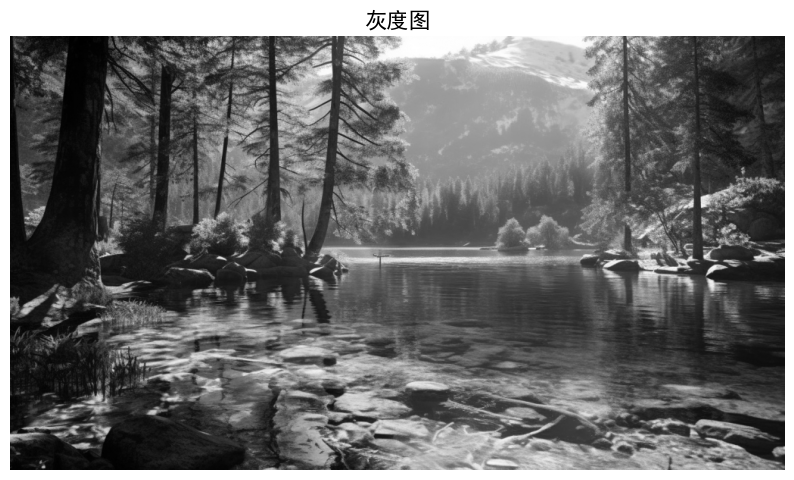

In [12]:
def rgb_to_gray(img):

    if len(img.shape) == 2:
        return img.astype(np.float32)
    
    # 加权平均
    gray = 0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]
    return gray.astype(np.float32)

img_gray = rgb_to_gray(img_array)

print(f"✅ 灰度转换完成！尺寸: {img_gray.shape}")

plt.figure(figsize=(10, 8))
plt.imshow(img_gray, cmap='gray')
plt.title("灰度图", fontsize=16)
plt.axis('off')
plt.show()

✅ 高斯核生成完成！
   核大小: 5x5, sigma=1.4
   高斯核数值:
[[ 1.9  4.2  5.4  4.2  1.9]
 [ 4.2  8.9 11.5  8.9  4.2]
 [ 5.4 11.5 14.9 11.5  5.4]
 [ 4.2  8.9 11.5  8.9  4.2]
 [ 1.9  4.2  5.4  4.2  1.9]]


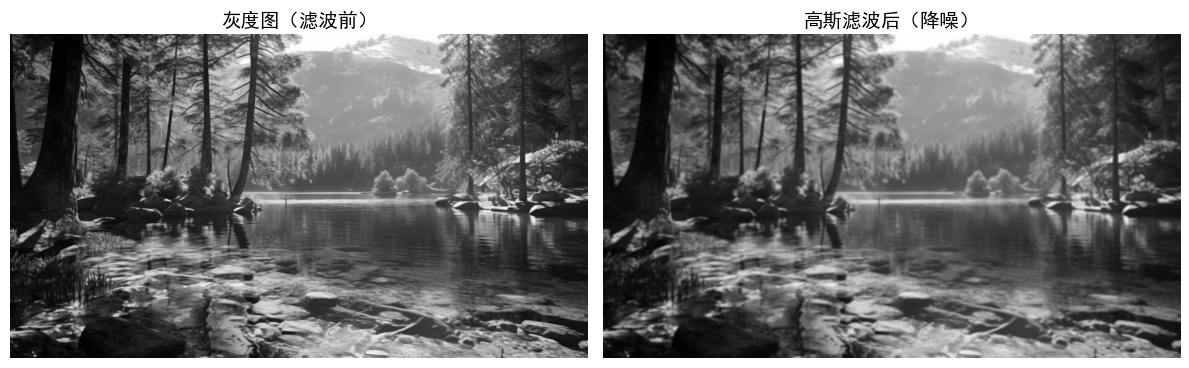

In [13]:
def gaussian_kernel(size=5, sigma=1.4):
    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2
    
    # 计算高斯核
    for i in range(size):
        for j in range(size):
            x = i - center
            y = j - center
            kernel[i, j] = (1 / (2 * np.pi * sigma**2)) * \
                           np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    # 归一化，使核的和为 1
    kernel = kernel / np.sum(kernel)
    return kernel

def convolve2d(img, kernel):
    """
    二维卷积（手动实现，不带 padding，边缘忽略）
    """
    h, w = img.shape
    k_h, k_w = kernel.shape
    pad_h = k_h // 2
    pad_w = k_w // 2
    
    # 填充边缘（镜像填充）
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    
    result = np.zeros((h, w), dtype=np.float32)
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+k_h, j:j+k_w]
            result[i, j] = np.sum(region * kernel)
    
    return result

# 生成高斯核并显示
sigma = 1.4
kernel_size = 5
gaussian_k = gaussian_kernel(kernel_size, sigma)

print("✅ 高斯核生成完成！")
print(f"   核大小: {kernel_size}x{kernel_size}, sigma={sigma}")
print("   高斯核数值:")
print(np.round(gaussian_k * 159, 1))  # 缩放显示，方便观察

# 应用高斯滤波
img_smooth = convolve2d(img_gray, gaussian_k)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("灰度图（滤波前）", fontsize=14)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_smooth, cmap='gray')
plt.title("高斯滤波后（降噪）", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

✅ Sobel 梯度计算完成！
   Gx 范围: [-409.38, 408.13]
   Gy 范围: [-382.39, 407.12]
   梯度幅值范围: [0.00, 426.15]


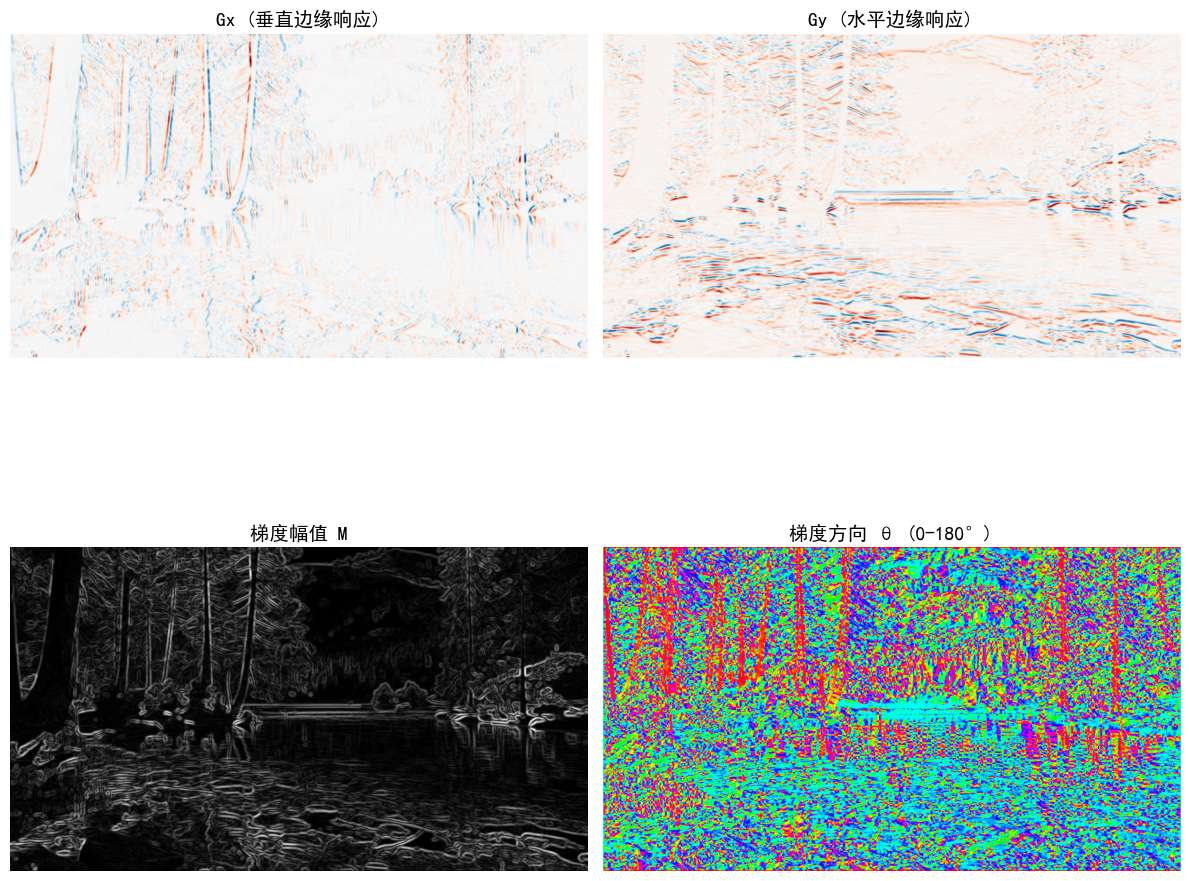

In [14]:
def sobel_gradients(img):

    # Sobel 核
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float32)
    
    sobel_y = np.array([[-1, -2, -1],
                        [ 0,  0,  0],
                        [ 1,  2,  1]], dtype=np.float32)
    
    Gx = convolve2d(img, sobel_x)
    Gy = convolve2d(img, sobel_y)
    
    return Gx, Gy

def gradient_magnitude_direction(Gx, Gy):

    M = np.sqrt(Gx**2 + Gy**2)
    theta = np.arctan2(Gy, Gx) * (180 / np.pi)  # 转换为角度
    theta = theta % 180  # 将角度归到 [0, 180)
    
    return M, theta

# 计算梯度
Gx, Gy = sobel_gradients(img_smooth)
M, theta = gradient_magnitude_direction(Gx, Gy)

# 归一化到 0-255 用于显示
M_display = (M / M.max() * 255).astype(np.uint8)

print("✅ Sobel 梯度计算完成！")
print(f"   Gx 范围: [{Gx.min():.2f}, {Gx.max():.2f}]")
print(f"   Gy 范围: [{Gy.min():.2f}, {Gy.max():.2f}]")
print(f"   梯度幅值范围: [{M.min():.2f}, {M.max():.2f}]")

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0,0].imshow(Gx, cmap='RdBu')
axes[0,0].set_title("Gx (垂直边缘响应)", fontsize=14)
axes[0,0].axis('off')

axes[0,1].imshow(Gy, cmap='RdBu')
axes[0,1].set_title("Gy (水平边缘响应)", fontsize=14)
axes[0,1].axis('off')

axes[1,0].imshow(M_display, cmap='gray')
axes[1,0].set_title("梯度幅值 M", fontsize=14)
axes[1,0].axis('off')

axes[1,1].imshow(theta, cmap='hsv')
axes[1,1].set_title("梯度方向 θ (0-180°)", fontsize=14)
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

✅ 非极大值抑制完成！
   NMS 后非零像素数: 107152
   NMS 前非零像素数: 587769


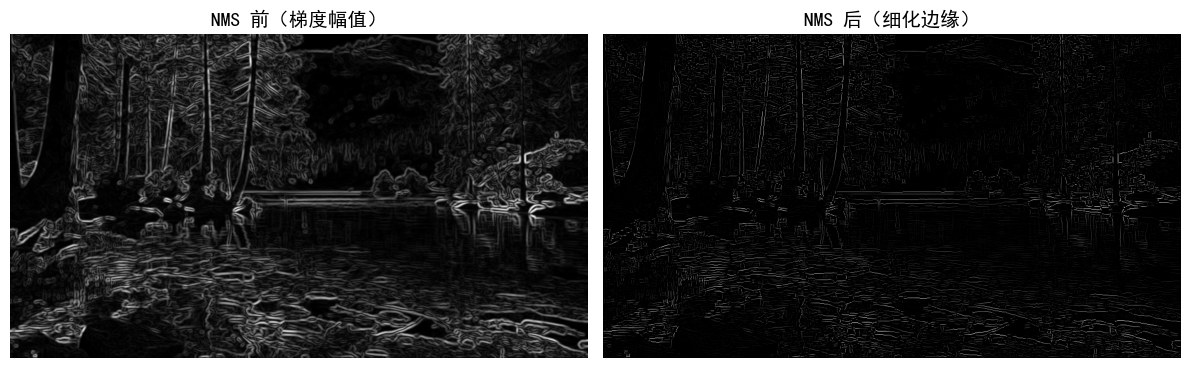

In [15]:
def non_max_suppression(M, theta):

    h, w = M.shape
    M_nms = np.zeros((h, w), dtype=np.float32)
    
    for i in range(1, h-1):
        for j in range(1, w-1):
            angle = theta[i, j]
            
            # 确定插值方向
            if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
                # 水平方向 (0°): 比较左右
                neighbors = [M[i, j-1], M[i, j+1]]
            elif (22.5 <= angle < 67.5):
                # 对角线方向 (45°): 比较右上和左下
                neighbors = [M[i-1, j+1], M[i+1, j-1]]
            elif (67.5 <= angle < 112.5):
                # 垂直方向 (90°): 比较上下
                neighbors = [M[i-1, j], M[i+1, j]]
            else:
                # 对角线方向 (135°): 比较左上和右下
                neighbors = [M[i-1, j-1], M[i+1, j+1]]
            
            # 保留局部极大值
            if M[i, j] >= max(neighbors):
                M_nms[i, j] = M[i, j]
    
    return M_nms

# 执行 NMS
M_nms = non_max_suppression(M, theta)
M_nms_display = (M_nms / M_nms.max() * 255).astype(np.uint8)

print("✅ 非极大值抑制完成！")
print(f"   NMS 后非零像素数: {np.count_nonzero(M_nms)}")
print(f"   NMS 前非零像素数: {np.count_nonzero(M)}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(M_display, cmap='gray')
plt.title("NMS 前（梯度幅值）", fontsize=14)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(M_nms_display, cmap='gray')
plt.title("NMS 后（细化边缘）", fontsize=14)
plt.axis('off')

plt.tight_layout()
plt.show()

✅ 双阈值检测与边缘连接完成！
   高阈值: 63.92
   低阈值: 21.31
   强边缘像素数: 41098
   弱边缘像素数: 36109
   最终边缘像素数: 45312


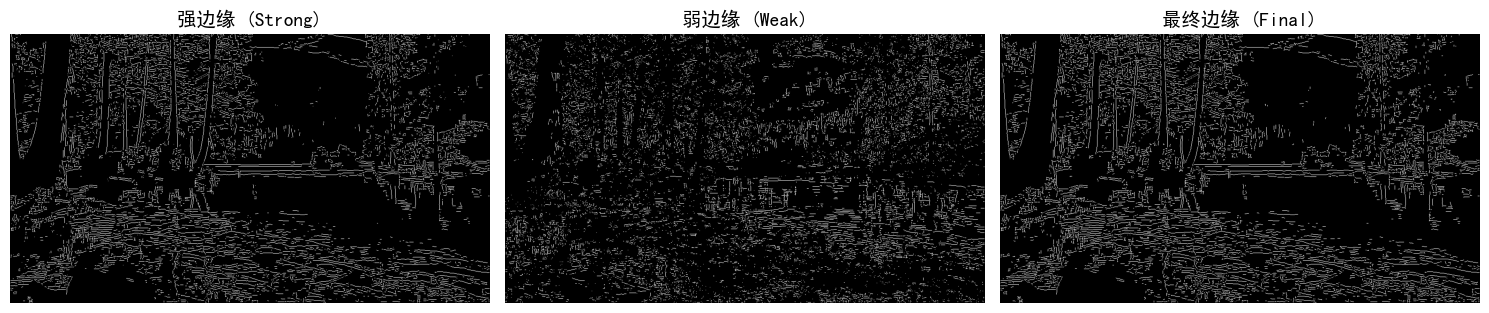

In [16]:
def double_threshold(M_nms, low_ratio=0.05, high_ratio=0.15):

    high_threshold = M_nms.max() * high_ratio
    low_threshold = M_nms.max() * low_ratio
    
    strong_edges = (M_nms >= high_threshold).astype(np.uint8)
    weak_edges = ((M_nms >= low_threshold) & (M_nms < high_threshold)).astype(np.uint8)
    
    return strong_edges, weak_edges, low_threshold, high_threshold

def hysteresis_tracking(strong, weak):

    h, w = strong.shape
    final_edges = strong.copy()
    
    # 找到所有弱边缘位置
    weak_points = np.argwhere(weak == 1)
    
    # 检查每个弱边缘点是否与强边缘连通
    for y, x in weak_points:
        # 8-邻域
        neighborhood = strong[max(0,y-1):min(h,y+2), max(0,x-1):min(w,x+2)]
        if np.any(neighborhood == 1):
            final_edges[y, x] = 1
    
    return final_edges

# 执行双阈值和边缘连接
strong, weak, low_th, high_th = double_threshold(M_nms, low_ratio=0.05, high_ratio=0.15)
final_edges = hysteresis_tracking(strong, weak)

print("✅ 双阈值检测与边缘连接完成！")
print(f"   高阈值: {high_th:.2f}")
print(f"   低阈值: {low_th:.2f}")
print(f"   强边缘像素数: {np.count_nonzero(strong)}")
print(f"   弱边缘像素数: {np.count_nonzero(weak)}")
print(f"   最终边缘像素数: {np.count_nonzero(final_edges)}")

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(strong, cmap='gray')
axes[0].set_title("强边缘 (Strong)", fontsize=14)
axes[0].axis('off')

axes[1].imshow(weak, cmap='gray')
axes[1].set_title("弱边缘 (Weak)", fontsize=14)
axes[1].axis('off')

axes[2].imshow(final_edges, cmap='gray')
axes[2].set_title("最终边缘 (Final)", fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [17]:
def canny_edge_detect(img, sigma=1.4, kernel_size=5, 
                      low_ratio=0.05, high_ratio=0.15):

    # Step 1: 灰度化
    gray = rgb_to_gray(img)
    
    # Step 2: 高斯滤波
    gaussian_k = gaussian_kernel(kernel_size, sigma)
    smooth = convolve2d(gray, gaussian_k)
    
    # Step 3: Sobel 梯度
    Gx, Gy = sobel_gradients(smooth)
    M, theta = gradient_magnitude_direction(Gx, Gy)
    
    # Step 4: NMS
    M_nms = non_max_suppression(M, theta)
    
    # Step 5: 双阈值 + 边缘连接
    strong, weak, low_th, high_th = double_threshold(M_nms, low_ratio, high_ratio)
    final = hysteresis_tracking(strong, weak)
    
    results = {
        'gray': gray,
        'smooth': smooth,
        'Gx': Gx, 'Gy': Gy,
        'M': M, 'theta': theta,
        'M_nms': M_nms,
        'strong': strong, 'weak': weak,
        'final': final
    }
    
    return final, results

# 一键运行
edges, results = canny_edge_detect(img_array, sigma=1.4, kernel_size=5, 
                                    low_ratio=0.05, high_ratio=0.15)

print("✅ Canny 边缘检测全部完成！")

✅ Canny 边缘检测全部完成！


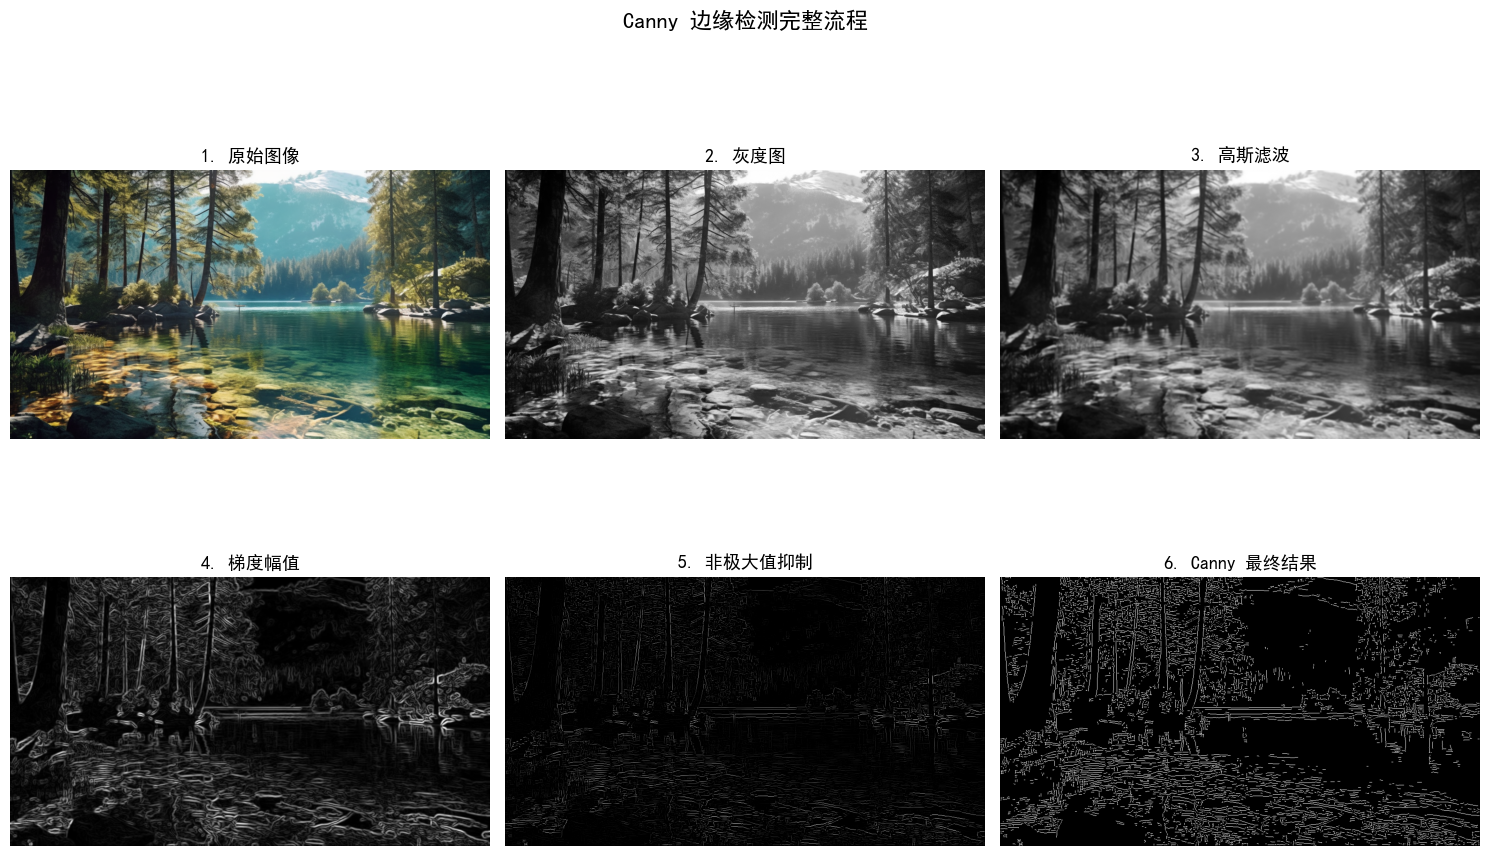

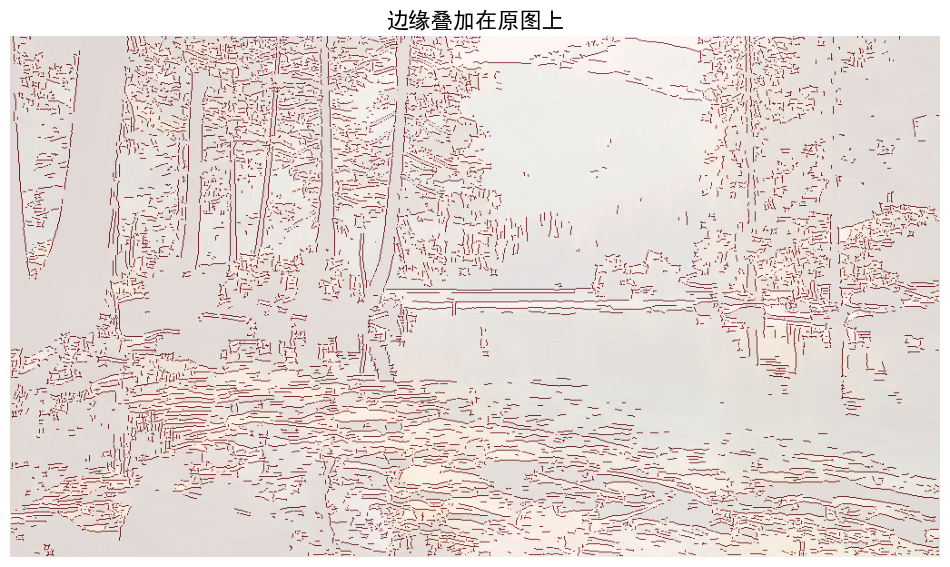

In [18]:
# 完整流程可视化
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0,0].imshow(img_array)
axes[0,0].set_title("1. 原始图像", fontsize=13)
axes[0,0].axis('off')

axes[0,1].imshow(results['gray'], cmap='gray')
axes[0,1].set_title("2. 灰度图", fontsize=13)
axes[0,1].axis('off')

axes[0,2].imshow(results['smooth'], cmap='gray')
axes[0,2].set_title("3. 高斯滤波", fontsize=13)
axes[0,2].axis('off')

axes[1,0].imshow(results['M'] / results['M'].max(), cmap='gray')
axes[1,0].set_title("4. 梯度幅值", fontsize=13)
axes[1,0].axis('off')

axes[1,1].imshow(results['M_nms'] / results['M_nms'].max(), cmap='gray')
axes[1,1].set_title("5. 非极大值抑制", fontsize=13)
axes[1,1].axis('off')

axes[1,2].imshow(results['final'], cmap='gray')
axes[1,2].set_title("6. Canny 最终结果", fontsize=13)
axes[1,2].axis('off')

plt.suptitle("Canny 边缘检测完整流程", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 与原图叠加显示
plt.figure(figsize=(12, 8))
plt.imshow(img_array, alpha=0.6)
plt.imshow(results['final'], cmap='Reds', alpha=0.8)
plt.title("边缘叠加在原图上", fontsize=16)
plt.axis('off')
plt.show()

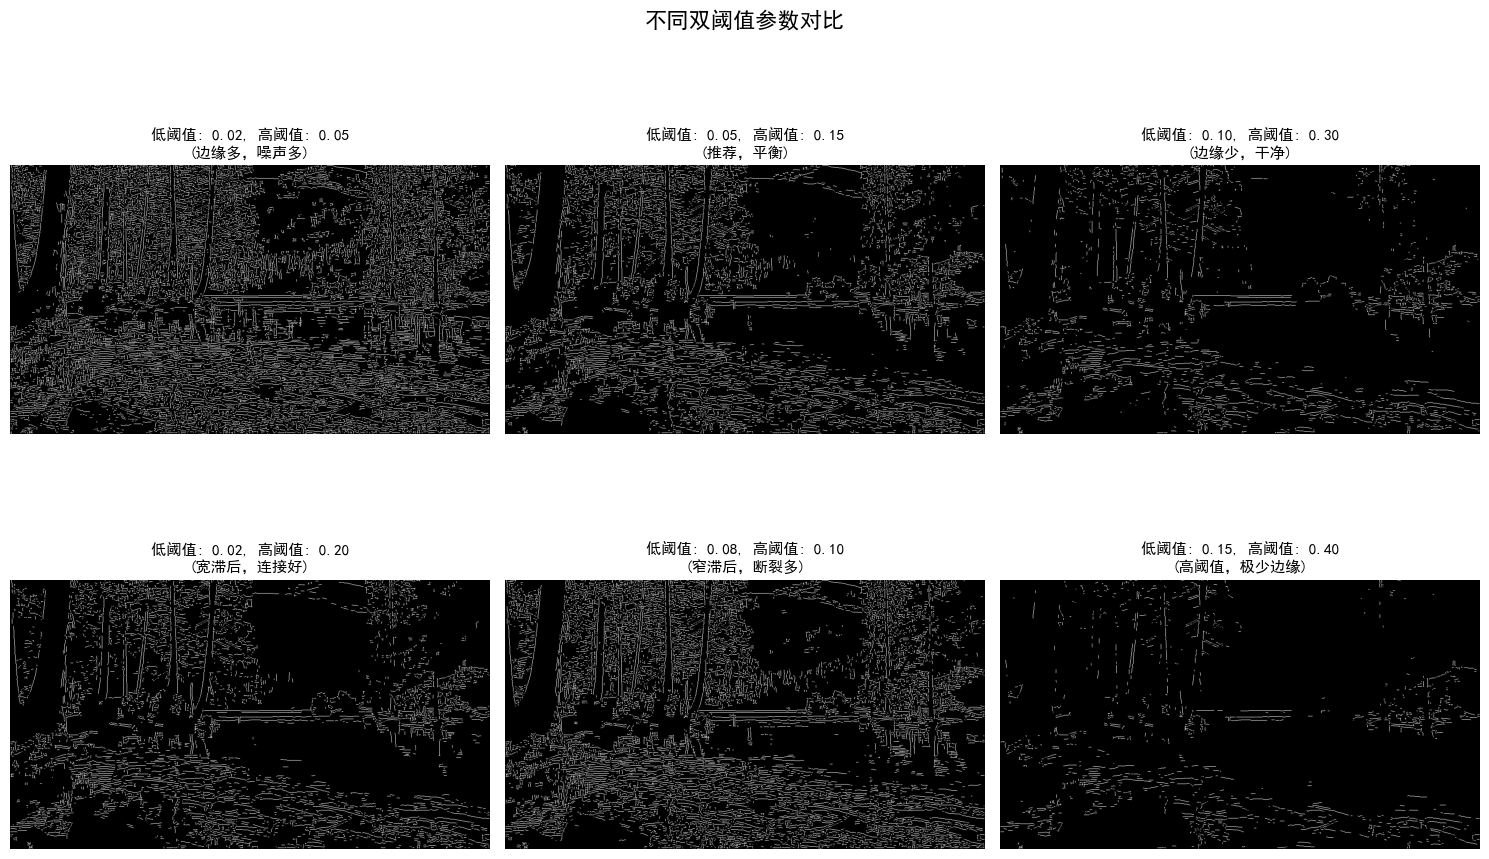

In [19]:
# 对比不同阈值的效果
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

params = [
    (0.02, 0.05, "低阈值: 0.02, 高阈值: 0.05\n(边缘多，噪声多)"),
    (0.05, 0.15, "低阈值: 0.05, 高阈值: 0.15\n(推荐，平衡)"),
    (0.10, 0.30, "低阈值: 0.10, 高阈值: 0.30\n(边缘少，干净)"),
    (0.02, 0.20, "低阈值: 0.02, 高阈值: 0.20\n(宽滞后，连接好)"),
    (0.08, 0.10, "低阈值: 0.08, 高阈值: 0.10\n(窄滞后，断裂多)"),
    (0.15, 0.40, "低阈值: 0.15, 高阈值: 0.40\n(高阈值，极少边缘)"),
]

for idx, (low, high, title) in enumerate(params):
    _, res = canny_edge_detect(img_array, sigma=1.4, kernel_size=5,
                                low_ratio=low, high_ratio=high)
    ax = axes[idx // 3, idx % 3]
    ax.imshow(res['final'], cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle("不同双阈值参数对比", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()